## Question / Hypothesis

**Question:** Does replacing the dictionary lexicon (v1) with FinBERT (v2) improve sentiment coverage enough to unlock a statistically viable analysis dataset?

**Assumptions:**
- **Data window:** 2024-02-08 – 2026-03-04 (Not actually 2 years worth of data, major missing gap. Only have about a )
- **Aggregation:** Daily (article_date × ticker)
- **Filtering (v1):** sentiment_present = True when sentiment_label != 'neutral'
- **Filtering (v2):** sentiment_present = True when |sentiment_score| > 0.05

## Data Loading

Load the FinBERT-scored article dataset. This file was produced by `scripts/add_sentiment_finbert.py` and contains all GDELT articles with continuous sentiment scores in [-1, +1].

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from msa.utils.paths import get_gdelt_with_sentiment

df = pd.read_parquet(get_gdelt_with_sentiment("parquet"))
df["seendate"] = pd.to_datetime(df["seendate"])

print(f"Loaded {len(df):,} articles")
print(f"Date range: {df['seendate'].min().date()} -> {df['seendate'].max().date()}")
print(f"Columns: {df.columns.tolist()}")


Loaded 12,557 articles
Date range: 2024-02-08 -> 2026-02-24
Columns: ['seendate', 'url', 'title', 'language', 'domain', 'socialimage', 'company', 'ticker', 'date', 'sentiment_score', 'sentiment_confidence', 'sentiment_label']


## Calculations

### Neutrality Rate: v1 vs v2

Compare the fraction of articles flagged as sentiment-present under each instrument.

In [23]:
MAG7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']

sample = df.sample(n=min(1000, len(df)), random_state=42)

label_counts = sample["sentiment_label"].value_counts()
label_pct = sample["sentiment_label"].value_counts(normalize=True).mul(100).round(1)

print(f"Label distribution (n={len(sample):,} sample):")
for label in label_counts.index:
    print(f"  {label:<10} {label_counts[label]:>5}  ({label_pct[label]:.1f}%)")

Label distribution (n=1,000 sample):
  neutral      569  (56.9%)
  positive     219  (21.9%)
  negative     212  (21.2%)


### Coverage Summary Table

Aggregate coverage metrics comparing both instruments across the MAG7 dataset.

In [24]:
# v1: label-based — sentiment_present when not neutral
v1 = df.copy()
v1["sentiment_present"] = v1["sentiment_label"] != "neutral"

# v2: score-based — sentiment_present when |score| > 0.05
v2 = df.copy()
v2["sentiment_present"] = v2["sentiment_score"].abs() > 0.05

v1_mag7 = v1[v1["ticker"].isin(MAG7)].copy()
v2_mag7 = v2[v2["ticker"].isin(MAG7)].copy()

# Documented v1 baseline from mag7_data_flow_analysis.md
V1_SENTIMENT_RATE = 0.44
V1_DAILY_PAIRS    = 462
V1_DAYS_5PLUS     = 55

print(f"v1 sentiment rate (label-based): {v1['sentiment_present'].mean():.1%}")
print(f"v2 sentiment rate (score-based): {v2['sentiment_present'].mean():.1%}")


v1 sentiment rate (label-based): 42.5%
v2 sentiment rate (score-based): 73.7%


In [25]:
rows = []
for label, df in [("v1", v1), ("v2", v2)]:
    filtered = df[df["sentiment_present"]]
    daily_tickers = filtered.groupby(pd.Grouper(key="seendate", freq="D"))["ticker"].nunique()
    rows.append({
        "version": label,
        "articles_with_sentiment": filtered.shape[0],
        "sentiment_rate": f'{df["sentiment_present"].mean():.1%}',
        "days_5plus_tickers": (daily_tickers >= 5).sum(),
        "mean_tickers_per_day": daily_tickers.mean().round(2),
    })
pd.DataFrame(rows)

,version,articles_with_sentiment,sentiment_rate,days_5plus_tickers,mean_tickers_per_day
0,v1,5335,42.5%,56,0.63
1,v2,9252,73.7%,57,0.65


In [26]:
print(f"{'Threshold':<12} {'Sentiment Present':>18} {'Neutrality Rate':>16}")
print("-" * 48)
for threshold in [0.0, 0.05, 0.1, 0.15, 0.2, 0.25]:
    rate = (df['sentiment_score'].abs() > threshold).mean()
    print(f"> {threshold:<10.2f} {rate:>17.1%} {1-rate:>15.1%}")

Threshold     Sentiment Present  Neutrality Rate
------------------------------------------------
> 0.00                  100.0%            0.0%
> 0.05                   73.7%           26.3%
> 0.10                   61.9%           38.1%
> 0.15                   55.1%           44.9%
> 0.20                   50.7%           49.3%
> 0.25                   47.6%           52.4%


### FinBERT Score Distribution

Visualize the distribution of raw FinBERT sentiment scores across all 12,557 articles.

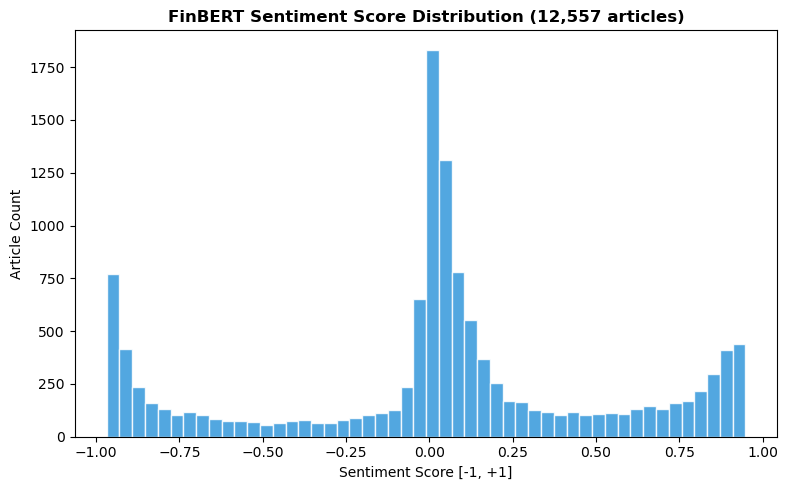

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["sentiment_score"], bins=50, color="#3498db", edgecolor="white", alpha=0.85)
plt.title(f"FinBERT Sentiment Score Distribution ({len(df):,} articles)", fontweight="bold")
plt.xlabel("Sentiment Score [-1, +1]")
plt.ylabel("Article Count")
plt.tight_layout()
plt.show()

### Per-Ticker Daily Coverage (v2)

For each MAG7 ticker, compute the mean and median number of sentiment-present articles per active day, along with total article count and number of active days.

In [21]:
def daily_coverage(df_in, label):
    filtered = df_in[df_in["sentiment_present"]].copy()
    filtered["date_only"] = filtered["seendate"].dt.normalize()
    coverage = filtered.groupby(["ticker", "date_only"]).size().reset_index(name="count")
    return (
        coverage.groupby("ticker")["count"]
        .agg(mean="mean", median="median", total="sum", days="count")
        .round(2)
        .add_prefix(f"{label}_")
    )

cov = daily_coverage(v1_mag7, "v1").join(daily_coverage(v2_mag7, "v2"))
print(cov.to_string())


        v1_mean  v1_median  v1_total  v1_days  v2_mean  v2_median  v2_total  v2_days
ticker                                                                              
AAPL       8.88        6.5       497       56    14.89       12.0       849       57
AMZN       9.86        7.0       582       59    17.13       16.0      1045       61
GOOGL     11.81        8.5      1063       90    19.34       16.0      1760       91
META      10.95        8.0       931       85    18.62       17.0      1657       89
MSFT      10.00        8.0       600       60    18.00       15.0      1116       62
NVDA      19.33       17.0      1218       63    32.24       29.0      2031       63
TSLA       7.28        6.0       444       61    12.41       11.5       794       64


### Coverage Histogram: v1 vs v2

For each calendar day, count how many MAG7 tickers had at least one sentiment-present article. The x-axis shows the number of MAG7 tickers covered (1–7); the y-axis shows how many days had that level of coverage.


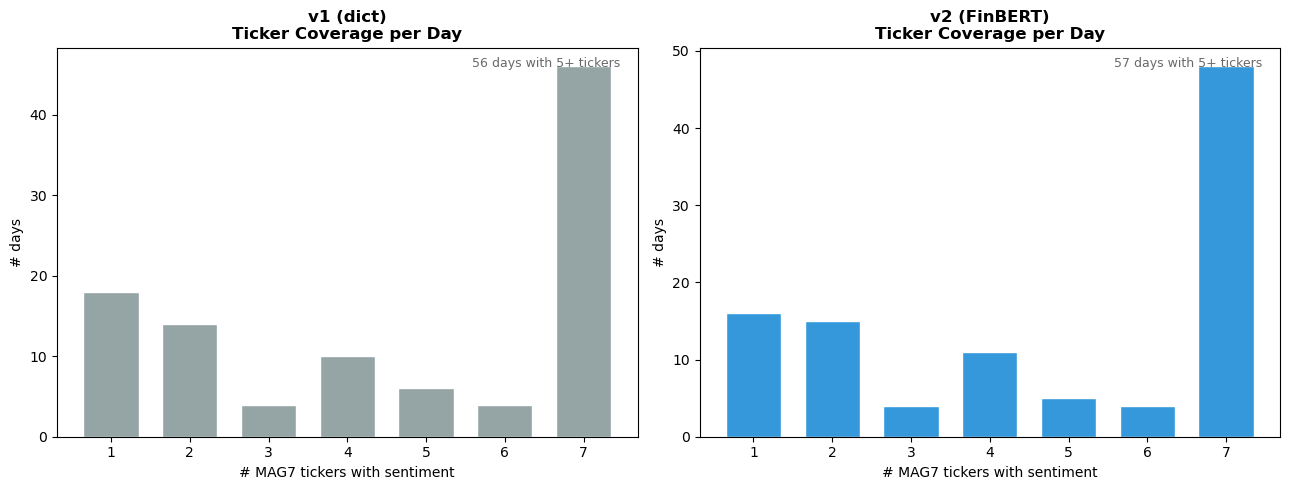

In [22]:
def daily_ticker_counts(df_in):
    filtered = df_in[df_in["sentiment_present"] & df_in["ticker"].isin(MAG7)].copy()
    filtered["date_only"] = filtered["seendate"].dt.normalize()
    return filtered.groupby("date_only")["ticker"].nunique()

tc_v1 = daily_ticker_counts(v1)
tc_v2 = daily_ticker_counts(v2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, tc, label, color in [
    (axes[0], tc_v1, "v1 (dict)", "#95a5a6"),
    (axes[1], tc_v2, "v2 (FinBERT)", "#3498db")]:

    counts = tc.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor="white", width=0.7)
    ax.set_title(f"{label}\nTicker Coverage per Day", fontweight="bold")
    ax.set_xlabel("# MAG7 tickers with sentiment")
    ax.set_ylabel("# days")
    ax.set_xticks(range(1, 8))
    days_5plus = int((tc >= 5).sum())
    ax.annotate(f"{days_5plus} days with 5+ tickers", xy=(0.97, 0.95),
                xycoords="axes fraction", ha="right", fontsize=9, color="dimgray")

plt.tight_layout()
plt.show()


## Conclusion / Next Steps

**Findings:**
- FinBERT (v2) represents a meaningful upgrade over the dictionary lexicon (v1) in how sentiment is captured. Rather than relying on keyword hits that leave more than 50% of articles unscored, FinBERT produces a continuous score in [-1, +1] for every article, giving us a much richer signal to work with.
- The 1k sample label distribution validates that the model is behaving as expected. Output is distributed across positive, negative, and neutral classes with no signs significantly false predictions.
- The score-based threshold |score| > 0.05 was chosen over label-based neutral filtering to maintain consistency between v1 and v2 comparisons while avoiding the hard cutoff that comes with treating the neutral label as a binary gate.
- Per-ticker daily coverage shows how consistently each MAG7 ticker is represented in the sentiment-present dataset on a day-by-day basis. Tickers with low active days or low article counts per day may be unreliable candidates for downstream modeling and should be interpreted cautiously.

**Next Steps:**
- Keep source bias in mind going into further analysis. Findings from Sprint 3 flagged that a small number of domains dominate article volume, which could distort aggregate sentiment even with FinBERT scoring in place.